In [141]:
from sklearn.datasets import  fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [156]:
dfk = pd.read_csv("data/king_ country_ houses_aa.csv")

<Axes: xlabel='price', ylabel='Count'>

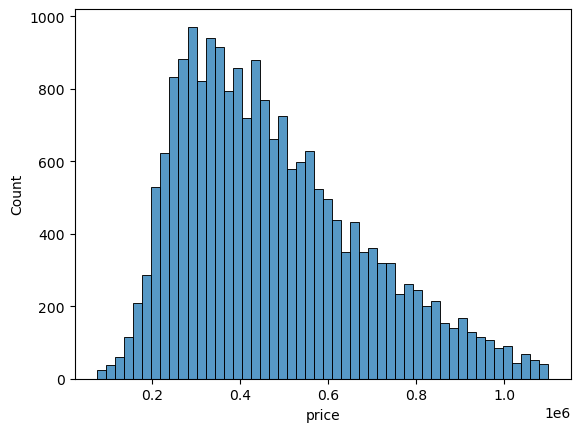

In [143]:
sns.histplot(data=dfk.price[dfk.price < 1100000])

In [144]:
#sns.histplot(data=dfkD['log_price'])

In [157]:

dfkD = dfk
dfkD['sale_year'] = pd.to_datetime(dfkD['date']).dt.year
dfkD['age_at_sale'] = dfkD['sale_year'] - dfkD['yr_built']

dfkD['living_to_lot_ratio'] = dfkD['sqft_living'] / dfkD['sqft_lot']

In [146]:
#sns.pairplot(dfkD, diag_kind='kde')

count    21613.000000
mean         3.370842
std          0.930062
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         33.000000
Name: bedrooms, dtype: float64

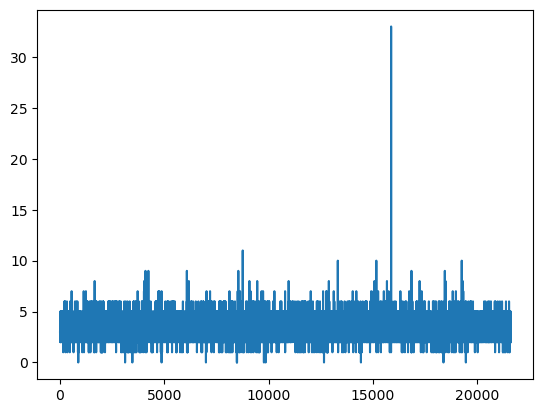

In [160]:
dfkD.bedrooms.plot()
dfkD.bedrooms.describe()

In [148]:
# coordinates of Seattle Downtown ca. (47.6062, -122.3321)
def haversine_distance(lat1, lon1, lat2=47.6062, lon2=-122.3321):
    r = 6371 # Erdradius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2)**2
    return r * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

dfkD['dist_to_seattle'] = haversine_distance(dfk['lat'], dfk['long'])

### no effect on model s effectiveness

In [149]:
#price is right skwed, so an attempt is
import numpy as np
dfkD['log_price']=np.log1p(dfkD['price'])


In [150]:
dfkD = dfkD[dfkD.columns.drop('price')]
dfkD = dfkD[dfkD.columns.drop('date')]
dfkD = dfkD[dfkD.columns.drop('id')]

In [ ]:
#suspicious no of rooms... when I take them out -> test performance decreases slightly
dfk3 = dfkD[dfkD['bedrooms'] < 32]
dfk2 = dfk3[dfk3['bedrooms'] > 0]
dfkD1 = dfk2[dfk2['bathrooms'] > 0]

### SPLIT

In [152]:
y = dfkD1.log_price
X = dfkD1[dfkD1.columns.drop('log_price')]


#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)

XGBoost builds one tree for each class and the trees for each class are called a “group” of trees, so output dimension may change due to used model. Internally, XGBoost attempts to extract the categories from the dataframe inputs. For inference (predict), the re-coding happens on the fly and there’s no data copy.

In [153]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

robust_features = ['sqft_lot', 'sqft_lot15', 'living_to_lot_ratio']

# Symmetrischere oder bereits log-transformierte Features -> StandardScaler
standard_features = ['sqft_living', 'sqft_above', 'age_at_sale', 'dist_to_seattle', 'lat', 'long']

# Kategoriale Features -> Keine Skalierung (nur One-Hot-Encoding)
categorical_features = ['zipcode'] 

# Pass-Through Features (bereits binär oder ordinal, z.B. waterfront, view, grade)
passthrough_features = ['waterfront', 'view', 'condition', 'grade', 'is_renovated']

# 2. Pipeline definieren
preprocessor = ColumnTransformer(
    transformers=[
        ('rob', RobustScaler(), robust_features),
        ('std', StandardScaler(), standard_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Behält passthrough_features unverändert
)

# 3. Fitten und Transformieren
# WICHTIG: Nur auf dem Train-Set fitten, um Data Leakage zu vermeiden!
X_train_scaled = preprocessor.fit_transform(train_X)
X_test_scaled = preprocessor.transform(test_X)

In [154]:
#xGBoostRegressor
import xgboost as xgb

xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(train_X, train_y)

y_pred = xgb_reg.predict(train_X)

print("#" * 23 + "XGBRegressor")
print("#" * 23 + "Train" + "#" * 23 )
trmse = mean_squared_error(train_y, y_pred)** (1 / 2)
train_mae = mean_absolute_error(train_y, y_pred)
tr2 = r2_score(train_y, y_pred)


print(f"Root Mean Squared Error: {trmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(train_mae))
print(f"R-squared Score       : {tr2:.2f}")

print("#" * 23 + "Test"  + "#" * 23 )
y_pred = xgb_reg.predict(test_X)
rmse = mean_squared_error(test_y, y_pred)** (1 / 2)
test_mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(test_mae))
print(f"R-squared Score        : {r2:.2f}")
print(f"R² Score    diff       : {tr2-r2:.3f}")

#######################XGBRegressor
#######################Train#######################
Root Mean Squared Error: 0.10
Mean Absolute Error    : 0.08
R-squared Score       : 0.96
#######################Test#######################
Root Mean Squared Error: 0.17
Mean Absolute Error    : 0.12
R-squared Score        : 0.90
R² Score    diff       : 0.064


In [155]:

dfkD1.to_csv('data/king_county_clean.csv', index=False)